In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

dataset_dir = Path(
    r"D:\FoodLens_AI\data\processed\foodlens_20"
)

train_images = dataset_dir / "train" / "images"
train_labels = dataset_dir / "train" / "labels"

classes_to_check = [
    "chapati",
    "naan",
    "daal",
    "aloo tikki"
]

class_ids = {
    "chapati": 0,
    "naan": 1,
    "daal": 2,
    "aloo tikki": 16
}

print("Dataset loaded.")

Dataset loaded.


In [2]:
for class_name in classes_to_check:

    class_id = class_ids[class_name]
    matching_images = []

    for label_file in train_labels.glob("*.txt"):

        with open(label_file, "r") as f:
            lines = f.readlines()

        found = False

        for line in lines:

            parts = line.strip().split()

            if len(parts) == 5:
                if int(parts[0]) == class_id:
                    found = True
                    break

        if found:

            image_path = train_images / (
                label_file.stem + ".jpg"
            )

            if image_path.exists():
                matching_images.append(image_path)

    print(
        f"{class_name}: "
        f"{len(matching_images)} images"
    )

chapati: 113 images
naan: 114 images
daal: 103 images
aloo tikki: 116 images


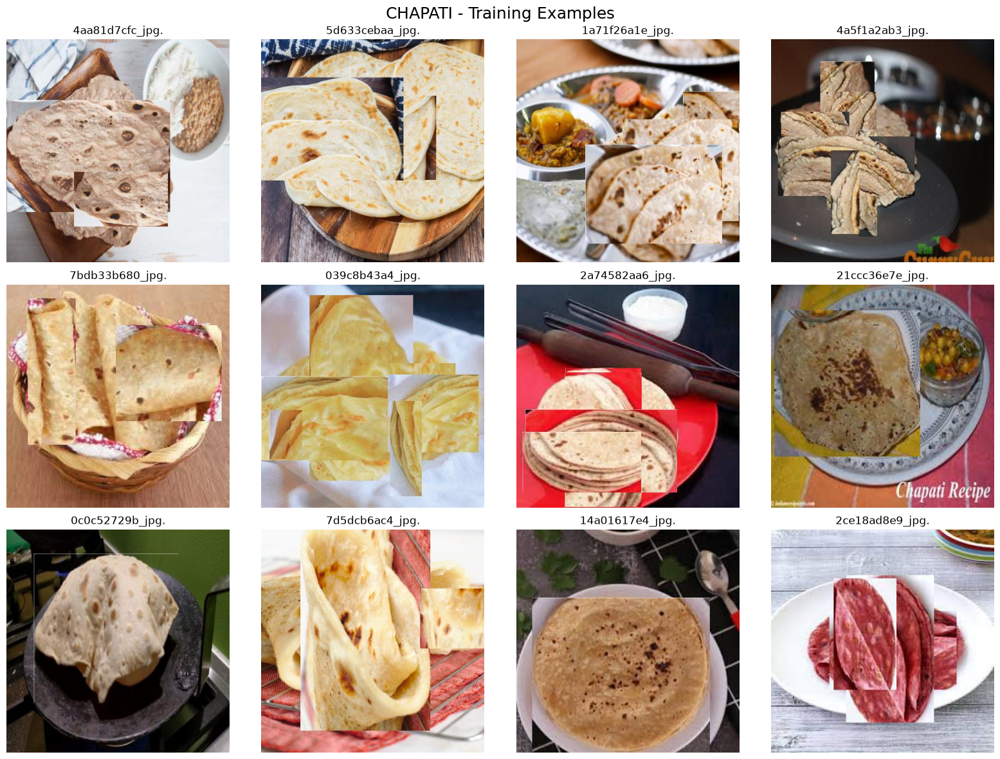

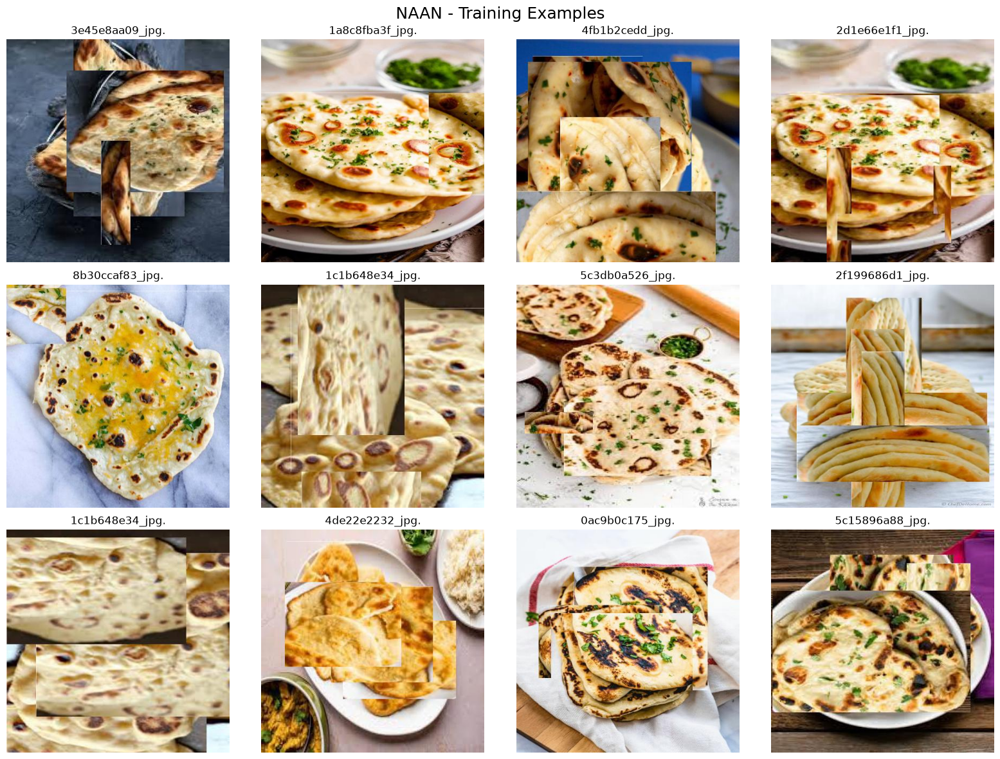

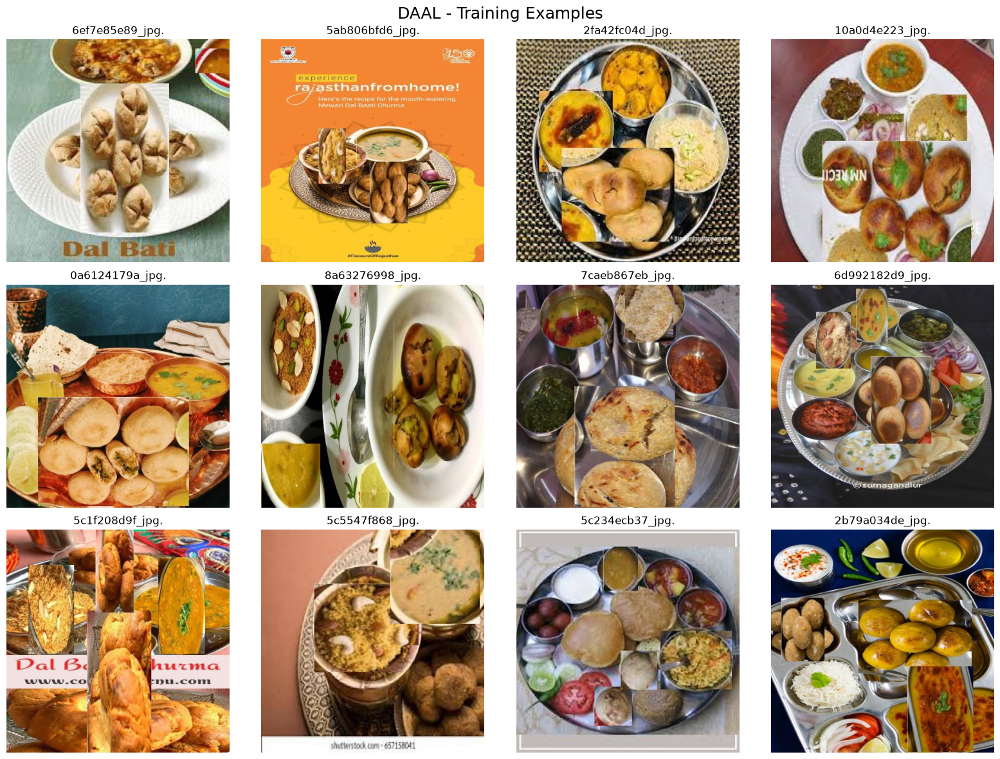

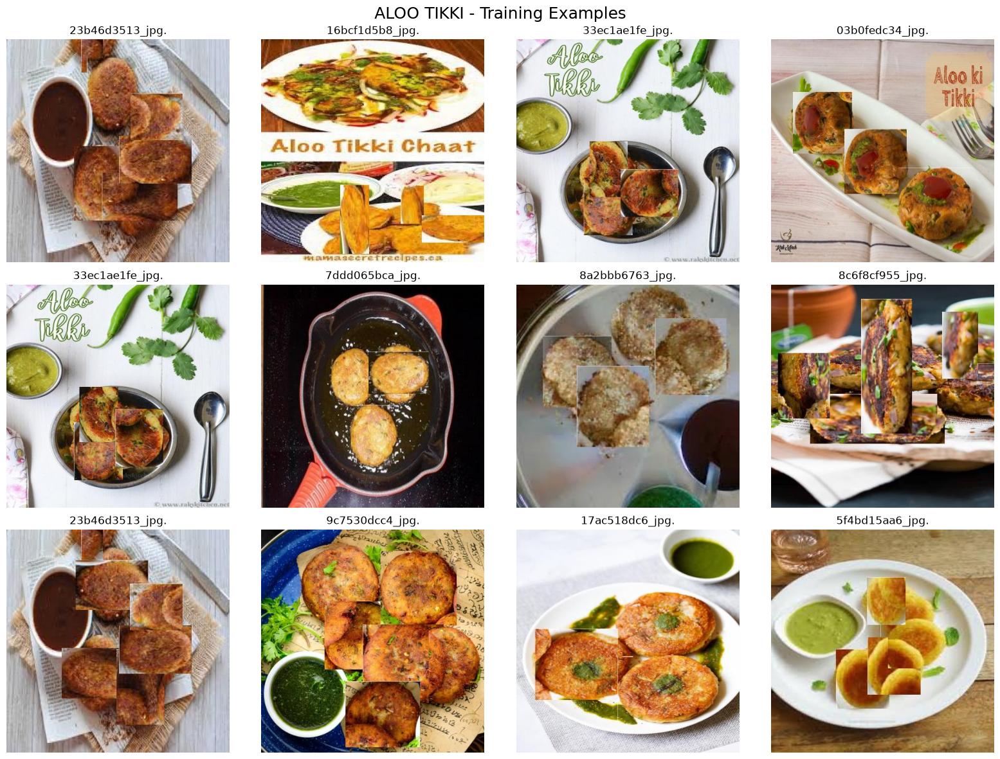

In [3]:
for class_name in classes_to_check:

    class_id = class_ids[class_name]

    matching_images = []

    for label_file in train_labels.glob("*.txt"):

        with open(label_file, "r") as f:
            lines = f.readlines()

        if any(
            len(line.strip().split()) == 5
            and int(line.strip().split()[0]) == class_id
            for line in lines
        ):

            image_path = train_images / (
                label_file.stem + ".jpg"
            )

            if image_path.exists():
                matching_images.append(image_path)

    samples = random.sample(
        matching_images,
        min(12, len(matching_images))
    )

    fig, axes = plt.subplots(
        3, 4,
        figsize=(16, 12)
    )

    fig.suptitle(
        f"{class_name.upper()} - Training Examples",
        fontsize=18
    )

    for ax, image_path in zip(axes.flat, samples):

        image = Image.open(image_path)

        ax.imshow(image)
        ax.set_title(image_path.name[:15])
        ax.axis("off")

    plt.tight_layout()
    plt.show()